# Face Detection using RetinaFace

## 1.0 Setup

In [2]:
# !pip install retinaface-pytorch

In [9]:
# utilities
import sys
import os
import shutil
import random
import json
import time
import multiprocessing
from pathlib import Path

# torch
import torch
import torch.nn as nn
from retinaface.pre_trained_models import get_model


# images/arrays
import numpy as np
import pandas as pd
import cv2
import PIL
import matplotlib.pyplot as plt
import seaborn as sns

# custom
from src.utils.functional import load_image_cv, expand_bbox

In [20]:
DATA_PATH = "/kaggle/input/datasets/ahmeddragabb/face-recognition-final"
DETECTOR_MAX_SIZE = 512
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [21]:
# detector
backbone_model = "resnet50_2020-07-20"
retina_face_detector = get_model(
    model_name = backbone_model,
    max_size = DETECTOR_MAX_SIZE,
    device = DEVICE
)

retina_face_detector.eval()

---
---

## 2.0 Detection

In [23]:
def detect_face(img, min_score = 0.90):
    """
    Detect best face using RetinaFace

    Returns:
        dict: {bbox, score, landmarks} or None
    """

    faces = retina_face_detector.predict_jsons(img)

    if not faces:
        return None

    # filter weak detections
    faces = [f for f in faces if f["score"] >= min_score]

    if not faces:
        return None

    # choose largest face (best for training)
    def face_area(f):
        x1, y1, x2, y2 = f["bbox"]
        return max(0, x2 - x1) * max(0, y2 - y1)

    best_face = max(faces, key = face_area)

    return best_face

In [25]:
def crop_face(image):
    """ 
    Detecting the face and cropping it 

    Args:
        image: a ndarry image

    Returned:
        cropped: the cropped_face
    """
    face = detect_face(img = image)
    bbox = expand_bbox(face["bbox"], image.shape[0], image.shape[1], margin_factor = 0.1)
    x1, y1, x2, y2 = bbox
    cropped = image[y1:y2, x1:x2]
    return cropped

In [26]:
# test
img_path = "/kaggle/input/datasets/ahmeddragabb/face-recognition-final/1/download (1).jpg"
img = load_image_cv(img_path)
img.shape

(225, 225, 3)

In [27]:
face = crop_face(img)
face.shape

(206, 141, 3)

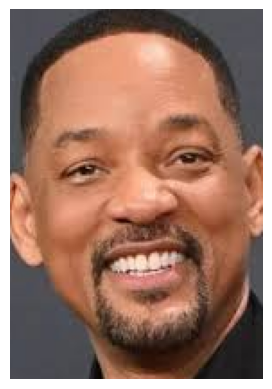

In [28]:
plt.imshow(face)
plt.axis("off")
plt.show()

**Detecting & Saving**

In [35]:
def detect_faces(source_data_path: str, destination_data_path: str):
    """
    Detect faces then save the results
    """
    all_persons = os.listdir(source_data_path)
    n_persons = len(all_persons)
    start_time = time.time()

    n_saved = 0
    n_failed = 0

    for idx, person_name in enumerate(all_persons, start = 1):
        person_path = os.path.join(source_data_path, person_name)
        dest_person_path = os.path.join(destination_data_path, person_name)
        os.makedirs(dest_person_path, exist_ok = True)

        if not os.path.isdir(person_path):
            continue


        person_images = os.listdir(person_path)

        for img_name in person_images:
            src_img_path = os.path.join(person_path, img_name)
            try:
                # get face
                img = load_image_cv(src_img_path)
                face = crop_face(img)

                # save face
                save_path = os.path.join(dest_person_path, img_name)
                saved = cv2.imwrite(
                    filename = save_path,
                    img = face
                )

                if saved: n_saved += 1
                else: 
                    n_failed += 1
                    print(f">> Failed to save: {src_img_path}"
                
            except Exception as e:
                print(f">> Error detecting the face in img: {src_img_path}")
                print(f">> The error: {e}")
                n_failed += 1
                continue

        if idx % 50 == 0:
            curr_time = time.time() - start_time
            print(
                f"Finished {idx}/{n_persons} persons "
                f"({idx/n_persons:.2%}) | "
                f"N_Saved: {n_saved} | N_Failed: {n_failed} | "
                f"Time: {curr_time/60:.2f} minutes"
            )
            
    print(f"Done. Saved: {saved} | Failed: {failed}")
    print(f"Destination: {destination_data_path}")

In [36]:
src_data_path = '/kaggle/input/datasets/ahmeddragabb/face-recognition-final'
dst_data_path = "/kaggle/working/face-recognition-detected"

os.makedirs(dst_data_path, exist_ok = True)

In [37]:
detect_faces(src_data_path, dst_data_path)

>> Error detecting the face in img: /kaggle/input/datasets/ahmeddragabb/face-recognition-final/19/imgres.htm
>> The error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'

>> Error detecting the face in img: /kaggle/input/datasets/ahmeddragabb/face-recognition-final/n000167/0382_01.jpg.jpg
>> The error: 'NoneType' object is not subscriptable
Finished 50/786 persons (6.36%) | N_Saved: 4674 | N_Failed: 2 | Time: 2.46 minutes
Finished 100/786 persons (12.72%) | N_Saved: 9408 | N_Failed: 2 | Time: 4.92 minutes
Finished 150/786 persons (19.08%) | N_Saved: 15166 | N_Failed: 2 | Time: 7.88 minutes
Finished 200/786 persons (25.45%) | N_Saved: 19306 | N_Failed: 2 | Time: 9.99 minutes
Finished 250/786 persons (31.81%) | N_Saved: 23408 | N_Failed: 2 | Time: 12.10 minutes
>> Error detecting the face in img: /kaggle/input/datasets/ahmeddragabb/face-recognition-final/n000154/0418_03.jpg.jpg
>> The error: 'NoneType' obje

NameError: name 'failed' is not defined

>> Total Persons: 786
>> Get 8 Random Images
Plot Images


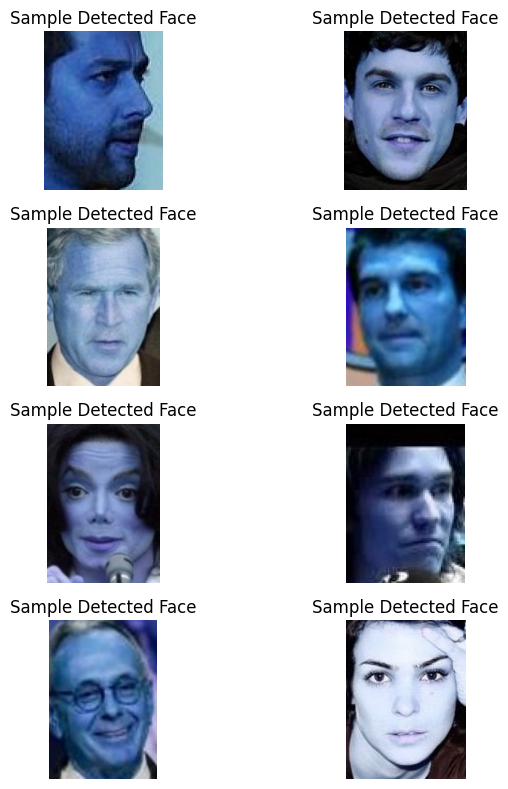

In [44]:
# test
all_persons = [os.path.join(dst_data_path, p) for p in os.listdir(dst_data_path)]

print(f">> Total Persons: {len(all_persons)}")

# get 8 random images
print(f">> Get 8 Random Images")
some_persons = random.choices(all_persons, k = 8)
some_images = []
for person in some_persons:
    person_images = os.listdir(person)
    random_img_name = random.choice(person_images)
    img_path = os.path.join(person, random_img_name)
    some_images.append(load_image_cv(image_path = img_path))

print(f"Plot Images")
print(100 * '=')

_, axes = plt.subplots(nrows = 4, ncols = 2, figsize = (8, 8))
for img, ax in zip(some_images, axes.flat):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Sample Detected Face")

plt.tight_layout()
plt.show()

## 3.0 Save

In [45]:
SOURCE_FOLDER = "/kaggle/working/face-recognition-detected"
UPLOAD_FOLDER = "/kaggle/working/upload_detected_dataset"

os.makedirs(UPLOAD_FOLDER, exist_ok = True)

In [46]:
zip_path = shutil.make_archive(
    base_name = os.path.join(UPLOAD_FOLDER, "data"),
    format = "zip",
    root_dir = SOURCE_FOLDER
)

print("Created:", zip_path)

Created: /kaggle/working/upload_detected_dataset/data.zip


In [47]:
metadata = {
    "title": "face-recognition-detected",
    "id": "ragabahmed/face-recognition-detected",
    "licenses": [{"name": "CC0-1.0"}]
}

with open(os.path.join(UPLOAD_FOLDER, "dataset-metadata.json"), "w") as f:
    json.dump(metadata, f, indent = 2)

In [48]:
!kaggle datasets create -p /kaggle/working/upload_detected_dataset

Starting upload for file data.zip
100%|███████████████████████████████████████| 1.07G/1.07G [00:11<00:00, 102MB/s]
Upload successful: data.zip (1GB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/ragabahmed/face-recognition-detected


---
---

***ALHAMDULILLAH***